In [5]:
import tempfile
import pickle
import sys
import traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from pprint import pprint

from scipy.special import logit, softmax
import os
import scipy.stats as stats
from os.path import join
import pickle as pkl
import bambi as bmb
import arviz as az
import numpy as np

import concurrent.futures
import numpy as np
import pandas as pd
from pathlib import Path
import pickle
import sys

from sklearn.metrics import balanced_accuracy_score


import numpy as np
import pandas as pd
from scipy.stats import linregress
import seaborn as sns
from scipy.interpolate import interp1d
from scipy.stats import zscore

In [86]:
df = pd.read_parquet('../data/generated/pupilometry/complete_pupil_df_feedback.pqt')

In [87]:

df = df.rename_axis('trial_num').reset_index()
df['target_next_trial'] = df['trial_num'] + 1
df = df.merge(
    df[['eid', 'trial_num', 'p_state1', 'p_state2','motivation_scalar']],
    left_on=['eid', 'target_next_trial'],
    right_on=['eid', 'trial_num'],
    how='left',
    suffixes=('', '_next')
)
df = df.drop(columns=['target_next_trial', 'trial_num_next'])
valid_consecutive_df = df.dropna(subset=['p_state1_next', 'p_state2_next', 'mean_pupil_size','std_pupil_size']).copy()

In [88]:
condition_left_congruent = (valid_consecutive_df['probabilityLeft'] == 0.8) & (valid_consecutive_df['signed_contrast'] >= 0)
condition_right_congruent = (valid_consecutive_df['probabilityLeft'] == 0.2) & (valid_consecutive_df['signed_contrast'] <= 0)
valid_consecutive_df['is_congruent'] = (condition_left_congruent | condition_right_congruent).astype(int)
valid_consecutive_df['feedback_binary'] = (valid_consecutive_df['feedbackType'] == 1.0).astype(int)
valid_consecutive_df['abs_contrast'] = np.abs(valid_consecutive_df['signed_contrast'])

In [90]:
# summary_stats = valid_consecutive_df.groupby(['feedbackType', 'is_congruent'])['mean_pupil_size'].agg(['mean', 'std', 'count'])
# print(summary_stats)

# plt.figure(figsize=(8, 6))
# sns.pointplot(
#     data=valid_consecutive_df, 
#     x='feedbackType', 
#     y='mean_pupil_size', 
#     hue='is_congruent',
#     dodge=True, 
#     capsize=.1,
#     err_kws={'linewidth': 1.5} # Adjusted for newer seaborn versions
# )
# plt.title('Post-Feedback Pupil Size by Feedback and is_congruent')
# plt.ylabel('Pupil Mean')
# plt.xlabel('Feedback')
# plt.show()

In [68]:
summary_stats_3way = valid_consecutive_df.groupby(['feedbackType', 'is_congruent', 'abs_contrast'])['mean_pupil_size'].agg(['mean', 'std', 'count']).reset_index()

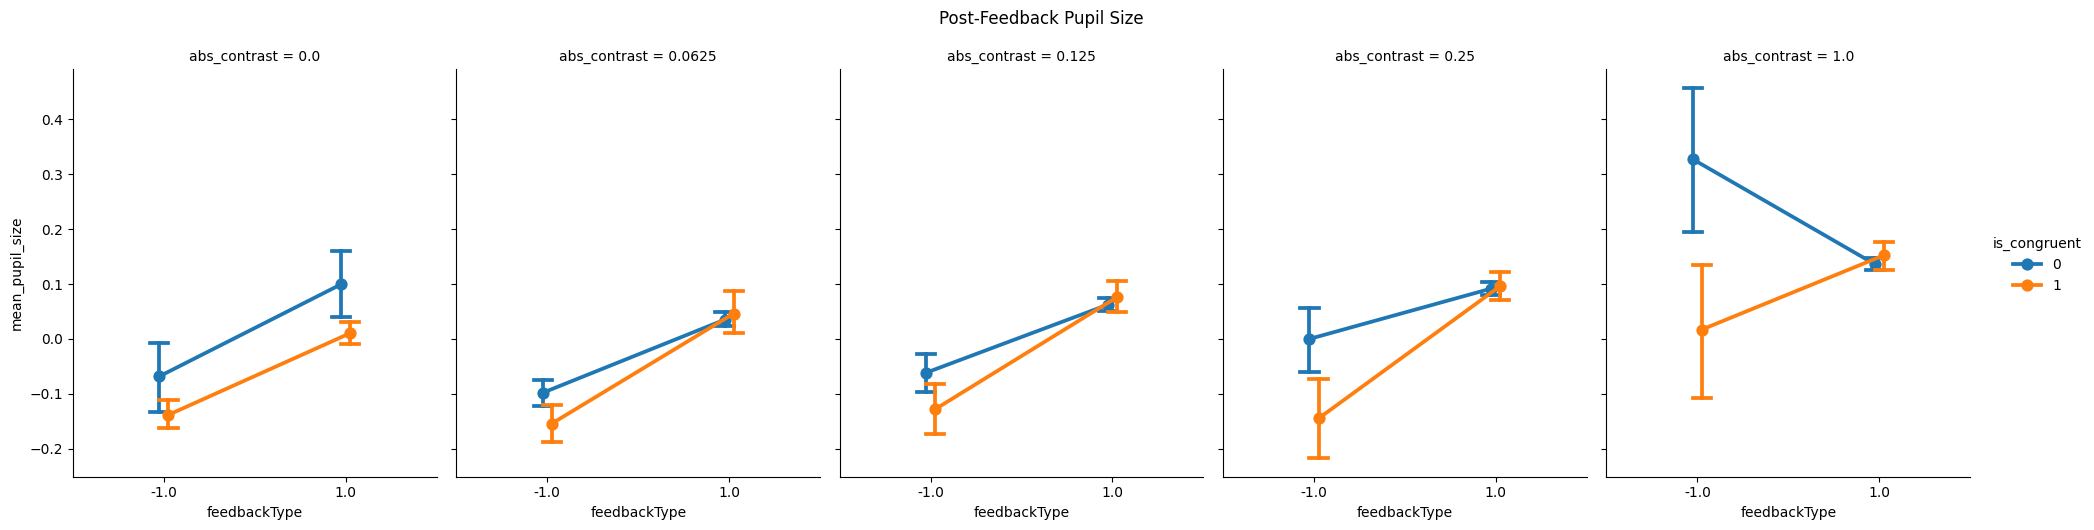

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

# catplot creates a grid of plots. 
# col='contrasts' means we get one distinct plot per contrast level.
g = sns.catplot(
    data=valid_consecutive_df,
    x='feedbackType',
    y='mean_pupil_size',
    hue='is_congruent',
    col='abs_contrast',
    kind='point',
    dodge=True,
    capsize=0.1,
    height=5,    
    aspect=0.8   
)

g.fig.suptitle('Post-Feedback Pupil Size', y=1.05)
plt.show()

In [ ]:
df = valid_consecutive_df.copy()



In [76]:
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np

def regress_out_contrast(group):
    valid_data = group.dropna(subset=['mean_pupil_size', 'abs_contrast'])
    
    res = pd.Series(np.nan, index=group.index)

    if len(valid_data)>2:
        model = smf.ols('mean_pupil_size ~ abs_contrast', data=valid_data).fit()
        res.loc[valid_data.index] = model.resid
    return res


df['residual_pupils'] = df.groupby('eid', group_keys=False).apply(regress_out_contrast)

/var/folders/nr/dw4dxrwd2r3ctns0lnz88jjc0000gn/T/ipykernel_7944/3570123092.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df['residual_pupils'] = df.groupby('eid', group_keys=False).apply(regress_out_contrast)


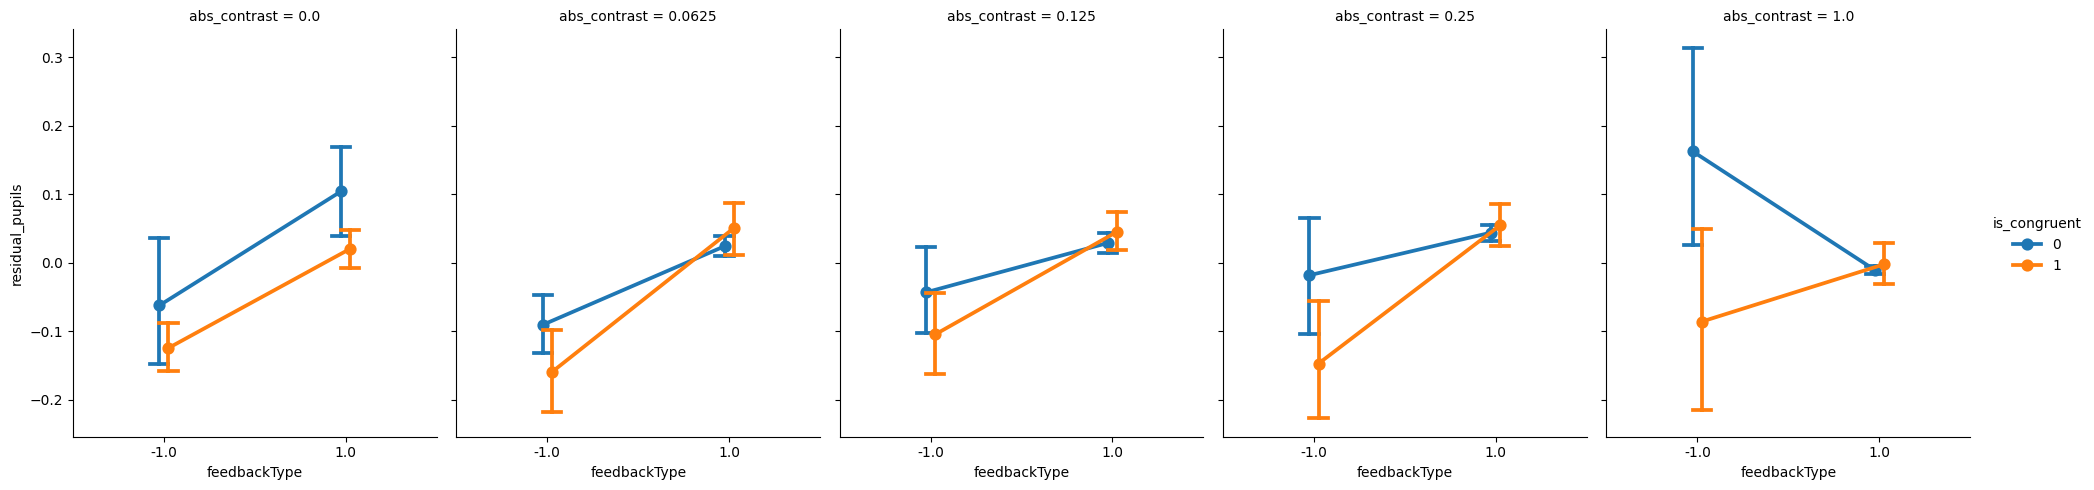

In [77]:
session_level_df = df.groupby(
    ['eid', 'feedbackType', 'is_congruent', 'abs_contrast']
)['residual_pupils'].mean().reset_index()

g = sns.catplot(
    data=session_level_df,  # Using the newly aggregated data!
    x='feedbackType',
    y='residual_pupils',
    hue='is_congruent',
    col='abs_contrast',     
    kind='point',        
    dodge=True,
    capsize=0.1,
    height=5,            
    aspect=0.8           
)

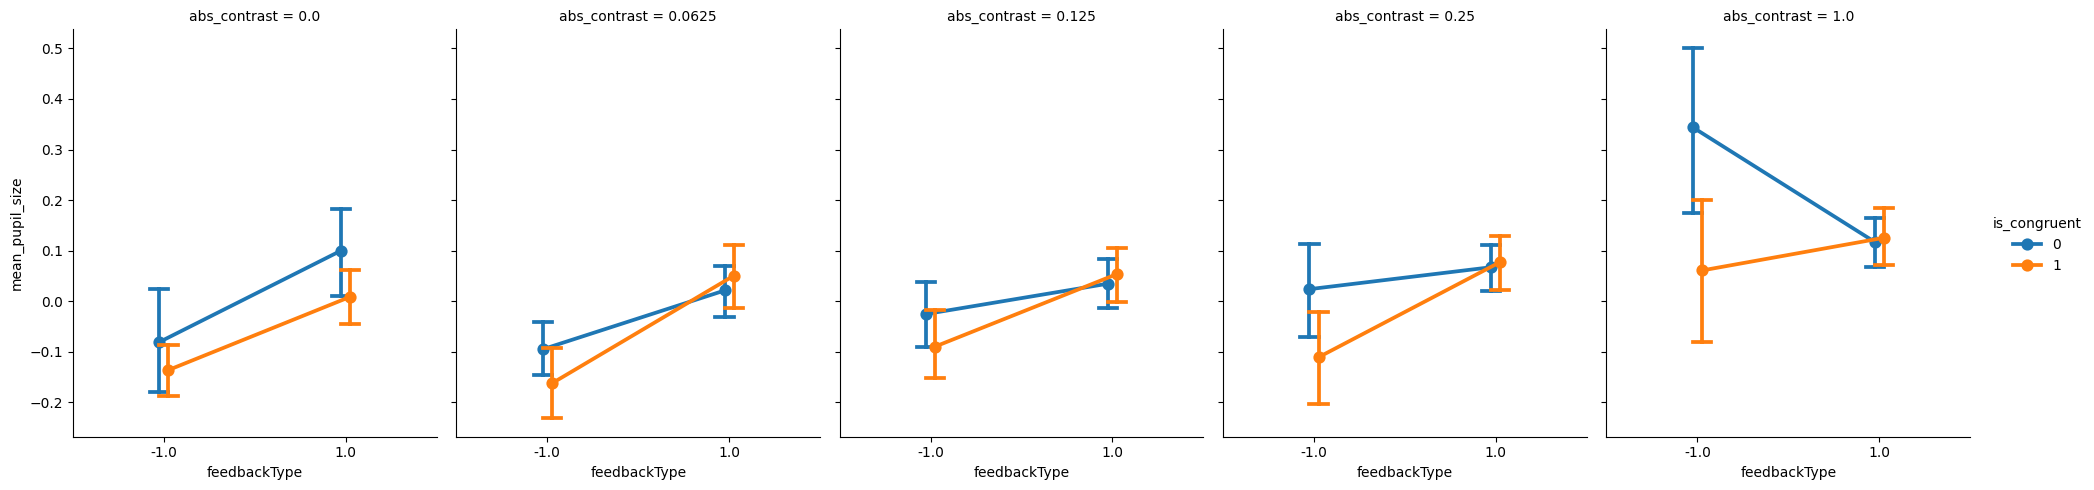

In [78]:
session_level_df = df.groupby(
    ['eid', 'feedbackType', 'is_congruent', 'abs_contrast']
)['mean_pupil_size'].mean().reset_index()

g = sns.catplot(
    data=session_level_df,  # Using the newly aggregated data!
    x='feedbackType',
    y='mean_pupil_size',
    hue='is_congruent',
    col='abs_contrast',     
    kind='point',        
    dodge=True,
    capsize=0.1,
    height=5,            
    aspect=0.8           
)

In [100]:
cols_to_keep = [
    'eid', 'mean_pupil_size', 'feedbackType', 
    'is_congruent', 'abs_contrast']
df_clean = valid_consecutive_df[cols_to_keep].copy()

# 2. Strip out single-element numpy arrays across all remaining columns
for col in df_clean.columns:
    df_clean[col] = df_clean[col].apply(
        lambda x: x.item() if isinstance(x, np.ndarray) and x.size == 1 else x
    )

# 3. Explicitly define the dtypes so Bambi (Patsy) parses them correctly
df_clean['eid'] = df_clean['eid'].astype(str)
df_clean['feedbackType'] = df_clean['feedbackType'].astype(float)
df_clean['is_congruent'] = df_clean['is_congruent'].astype(float)
df_clean['abs_contrast'] = df_clean['abs_contrast'].astype(float)
df_clean['mean_pupil_size'] = df_clean['mean_pupil_size'].astype(float)

In [105]:
import bambi as bmb

formula = 'mean_pupil_size ~ C(feedbackType) + C(is_congruent) + C(abs_contrast) + (1|eid)'
model = bmb.Model(formula, data=df_clean)
results = model.fit(draws=2000, tune=1000, chains=4, target_accept=0.9)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, C(feedbackType), C(is_congruent), C(abs_contrast), 1|eid_sigma, 1|eid_offset]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 122 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


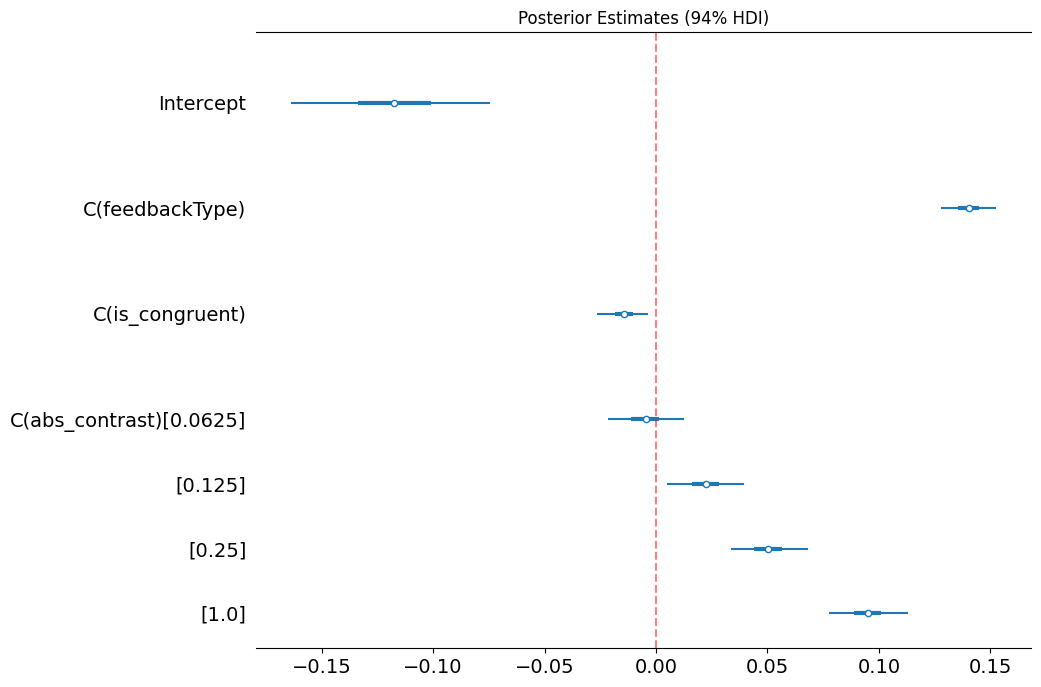

In [106]:
import arviz as az
import matplotlib.pyplot as plt

az.plot_forest(
    results, 
    var_names=['Intercept', 'feedbackType', 'is_congruent', 'abs_contrast'], 
    filter_vars='like', 
    combined=True, 
    hdi_prob=0.94,
    figsize=(10, 8)
)
plt.axvline(0, color='red', linestyle='--', alpha=0.5)
plt.title('Posterior Estimates (94% HDI)')
plt.show()